In [ ]:
"""This code performs data preprocessing, trains a linear regression model to predict house prices, evaluates the model, and visualizes the results using residual and scatter plots.

"""


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
file_path = "boston_housing.csv"
boston_data = pd.read_csv(file_path)

In [3]:
print("Boston Housing Dataset")
print(boston_data.head())


Boston Housing Dataset
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [4]:
print("Missing values")
print(boston_data.isnull().sum())

Missing values
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [5]:
boston_data.dropna(inplace=True)

In [6]:
print("Missing values after cleaning")
print(boston_data.isnull().sum())

Missing values after cleaning
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [7]:
print("Dataset info")
print(boston_data.info())

Dataset info
<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     394 non-null    float64
 1   ZN       394 non-null    float64
 2   INDUS    394 non-null    float64
 3   CHAS     394 non-null    float64
 4   NOX      394 non-null    float64
 5   RM       394 non-null    float64
 6   AGE      394 non-null    float64
 7   DIS      394 non-null    float64
 8   RAD      394 non-null    int64  
 9   TAX      394 non-null    int64  
 10  PTRATIO  394 non-null    float64
 11  B        394 non-null    float64
 12  LSTAT    394 non-null    float64
 13  MEDV     394 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 46.2 KB
None


In [8]:
print("Dataset stats")
print(boston_data.describe())

Dataset stats
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  394.000000  394.000000  394.000000  394.000000  394.000000  394.000000   
mean     3.690136   11.460660   11.000863    0.068528    0.553215    6.280015   
std      9.202423   23.954082    6.908364    0.252971    0.113112    0.697985   
min      0.006320    0.000000    0.460000    0.000000    0.389000    3.561000   
25%      0.081955    0.000000    5.130000    0.000000    0.453000    5.879250   
50%      0.268880    0.000000    8.560000    0.000000    0.538000    6.201500   
75%      3.435973   12.500000   18.100000    0.000000    0.624000    6.605500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  394.000000  394.000000  394.000000  394.000000  394.000000  394.000000   
mean    68.932741    3.805268    9.403553  406.431472   18.537563  358.490939   
std     27.88

In [9]:
X = boston_data.drop('MEDV', axis=1)
Y = boston_data['MEDV']

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, Y_train)

LinearRegression()

In [13]:
Y_pred = model.predict(X_test)

In [14]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

In [15]:
print("Model Evaluation")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2) Score: {r2}")

Model Evaluation
Mean Squared Error (MSE): 31.454047664950963
R-squared (R2) Score: 0.627084994167318


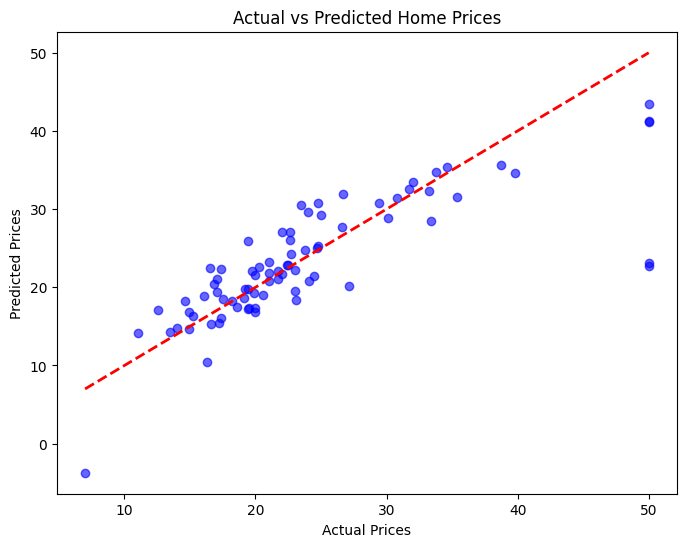

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, color='blue', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Home Prices')
plt.show()

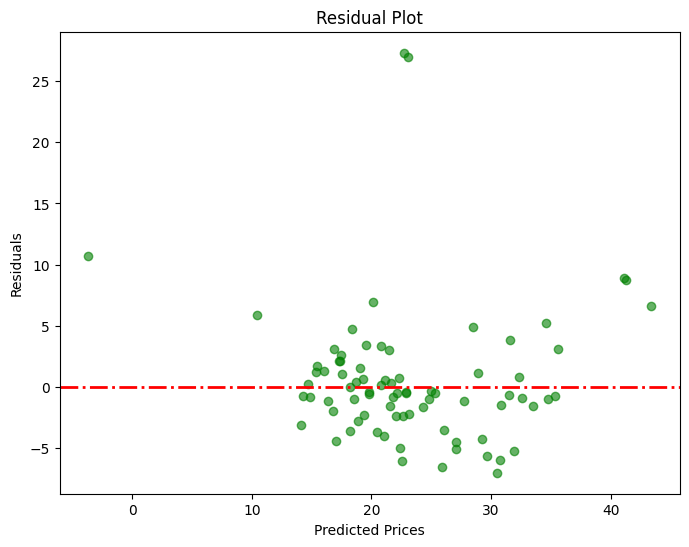

In [17]:
residuals = Y_test - Y_pred
plt.figure(figsize=(8,6))
plt.scatter(Y_pred, residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='-.', lw=2)
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
"""2.1 Importing Required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
pandas: Used to handle data in DataFrame format.

numpy: Provides support for numerical operations (used indirectly).

seaborn: Used for statistical data visualization (though not used directly here).

matplotlib.pyplot: Used for plotting graphs, especially scatter plots.

train_test_split: Splits the data into training and testing sets.

LinearRegression: Used to create and train a linear regression model.

mean_squared_error, r2_score: Used to evaluate the performance of the regression model.

2.2 Loading and Previewing the Dataset

file_path = "boston_housing.csv"
boston_data = pd.read_csv(file_path)
print("Boston Housing Dataset")
print(boston_data.head())
Reads the dataset from the provided CSV file path (boston_housing.csv).

Displays the first 5 rows of the dataset to get an overview of the features.

2.3 Checking and Handling Missing Values

print("Missing values")
print(boston_data.isnull().sum())
Checks for missing values in the dataset by summing the null values in each column.

Outputs the count of missing values per column.


boston_data.dropna(inplace=True)
print("Missing values after cleaning")
print(boston_data.isnull().sum())
Drops any rows with missing values using dropna().

After cleaning, checks again for missing values to confirm they are removed.

2.4 Dataset Information and Summary Statistics

print("Dataset info")
print(boston_data.info())
Displays general information about the dataset, such as data types and non-null count of each column.


print("Dataset stats")
print(boston_data.describe())
Displays summary statistics for numerical columns, such as count, mean, standard deviation, min, max, and quartiles.

2.5 Defining Features and Target Variable

X = boston_data.drop('MEDV', axis=1)
Y = boston_data['MEDV']
X contains all columns except for MEDV (Median value of owner-occupied homes), which will be the target variable.

Y contains the target variable MEDV.

2.6 Splitting Data into Training and Testing Sets

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
Splits the data into training and testing sets using train_test_split().

test_size=0.2 means 20% of the data is used for testing, and random_state=42 ensures reproducibility.

2.7 Training the Linear Regression Model

model = LinearRegression()
model.fit(X_train, Y_train)
Creates an instance of the LinearRegression model and fits it to the training data (X_train and Y_train).

2.8 Making Predictions and Model Evaluation

Y_pred = model.predict(X_test)
Uses the trained model to predict the target variable (Y_pred) on the test data (X_test).


mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print("Model Evaluation")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2) Score: {r2}")
Calculates the Mean Squared Error (MSE) and R-squared (R2) score to evaluate the model’s performance.

MSE: Measures the average squared difference between predicted and actual values.

R2: Measures how well the model explains the variance in the target variable (closer to 1 means better).

2.9 Visualizing Actual vs Predicted Home Prices

plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, color='blue', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Home Prices')
plt.show()
Creates a scatter plot comparing the actual home prices (Y_test) vs the predicted prices (Y_pred).

The red dashed line represents the ideal case where actual prices equal predicted prices.

A well-fitting model will have points close to the red line.

2.10 Visualizing Residuals

residuals = Y_test - Y_pred
plt.figure(figsize=(8,6))
plt.scatter(Y_pred, residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='-.', lw=2)
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
Calculates the residuals (difference between actual and predicted prices).

Plots the residuals against the predicted values (Y_pred).

A well-behaved model will show residuals randomly distributed around zero, with no patterns or trends."""